In [1]:

import torch
import timm
import os
import pandas as pd
from PIL import Image
import numpy as np
import torchvision.transforms as T
from torchvision.transforms import Compose, Normalize, ToTensor
from tqdm import tqdm
import cv2

from pytorch_grad_cam import ShapleyCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputSoftmaxTarget, ClassifierOutputReST
from pytorch_grad_cam.metrics.ADCC import ADCC
from pytorch_grad_cam.utils.image import show_cam_on_image

/Users/user/Documents/Inno/XAI/swin_shapleycam/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/user/Documents/Inno/XAI/swin_shapleycam/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_swin_transformer(checkpoint_path: str, num_classes: int, model_name: str = 'swin_tiny_patch4_window7_224'):

    model = timm.create_model(model_name, pretrained=False, num_classes=num_classes)

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file not found at {checkpoint_path}")
    print(f"Loading checkpoint from: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location='cpu') # Load to CPU first

    state_dict = checkpoint.get('model', checkpoint) # Check if 'model' key exists
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k[7:] if k.startswith('module.') else k
        new_state_dict[name] = v
    msg = model.load_state_dict(new_state_dict, strict=False)
    print(f"Model loading message: {msg}")
    model.eval()
    print(f"Successfully loaded model '{model_name}' from checkpoint.")
    return model

In [3]:
NUM_CLASSES = 43
CHECKPOINT_FILE = 'models/swin_tiny_gtsrb.pth'

try:
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Using device: {device}")
    swin_model = load_swin_transformer(CHECKPOINT_FILE, NUM_CLASSES, model_name='swin_tiny_patch4_window7_224')
    swin_model.to(device)
    print("Model ready for use.")
except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(f"An error occurred during model loading: {e}")

target_layers = [swin_model.norm]

Using device: mps
Loading checkpoint from: models/swin_tiny_gtsrb.pth
Model loading message: <All keys matched successfully>
Successfully loaded model 'swin_tiny_patch4_window7_224' from checkpoint.
Model ready for use.


In [4]:
def reshape_transform(result, height=7, width=7):
    result = result.transpose(2, 3).transpose(1, 2)
    return result

cam = ShapleyCAM(
    model=swin_model,
    target_layers=target_layers,
    reshape_transform=reshape_transform,
)

print(f"Initialized with target layers: {[type(layer).__name__ for layer in target_layers]}")

Initialized with target layers: ['LayerNorm']


In [5]:
df_test = pd.read_csv('data/test.csv')
image_folder = 'data/'
output_folder = 'data/atn_maps'

img_size = 224
transform = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # ImageNet stats
])

cam_metric = ADCC()

# --- Evaluation Loop ---
pointing_game_hits = 0
iou_scores = []
total_adcc = 0
total_avg_drop = 0
total_coherency = 0
total_complexity = 0
total_inc = 0
total_dropindeletion = 0
num_images = df_test.shape[0]
# Add lists for insertion/deletion scores if calculating

for index, row in tqdm(df_test.iterrows(), total=df_test.shape[0], desc="Evaluating ShapleyCAM"):
    image_path = os.path.join(image_folder, row['Path']) # Check 'Path' is the correct column name
    if not os.path.exists(image_path):
        print(f"Warning: Image not found at {image_path}. Skipping row {index}.")
        continue # Skip if image doesn't exist

    img = np.array(Image.open(image_path))

    img = np.array(Image.fromarray(img).resize((224, 224)))
    img = np.float32(img) / 255
    
    preprocessing = Compose([
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    input_tensor = preprocessing(img.copy()).unsqueeze(0)
    input_tensor = input_tensor.to(device)
    # --- Get Model Prediction ---
    with torch.no_grad():
        output = swin_model(input_tensor)
        probabilities = torch.softmax(output, dim=1)
        # print(probabilities)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        # Optional: Use ground truth class if needed by some metrics
        target_class = int(row['ClassId']) # Check 'ClassId' is the correct column name

    # --- Define CAM Target (Using Predicted Class for most CAM evaluations) ---
    metric_targets = [ClassifierOutputSoftmaxTarget(predicted_class)]
    cam_targets = [ClassifierOutputReST(predicted_class)]
    # --- Compute ShapleyCAM ---
    # Ensure cam object exists and is configured
    grayscale_cam = cam(input_tensor=input_tensor, 
                                    targets=cam_targets, eigen_smooth=False, aug_smooth=False)
    grayscale_cam = grayscale_cam[0, :] # Get single map from batch
    # --- Basic Evaluations ---
    # Pointing Game & IoU require resizing CAM to original image dimensions
    try:
        original_width = int(row['Width'])
        original_height = int(row['Height'])
        # Resize using PIL (avoids cv2 dependency if not needed otherwise)
        cam_resized_pil = Image.fromarray((grayscale_cam * 255).astype(np.uint8)).resize((original_width, original_height), Image.BILINEAR)
        cam_resized = np.array(cam_resized_pil) / 255.0
        # Save the attention map as an image
        attention_map = (grayscale_cam - grayscale_cam.min()) / (grayscale_cam.max() - grayscale_cam.min())  # Normalize the CAM
        attention_map_pil = Image.fromarray((attention_map * 255).astype(np.uint8)).convert("L")  # Convert to PIL image in grayscale
        attention_map_path = os.path.join(output_folder, f"attention_map_{index}.png")  # Define the output path
        attention_map_pil.save(attention_map_path)  # Save the attention map image
        # Pointing Game
        max_point_coords = np.unravel_index(np.argmax(cam_resized, axis=None), cam_resized.shape)
        y_max, x_max = max_point_coords
        roi_x1, roi_y1, roi_x2, roi_y2 = int(row['Roi.X1']), int(row['Roi.Y1']), int(row['Roi.X2']), int(row['Roi.Y2'])
        if roi_x1 <= x_max < roi_x2 and roi_y1 <= y_max < roi_y2:
            pointing_game_hits += 1

        # IoU
        threshold = 0.5 # Adjust threshold as needed
        cam_mask = (cam_resized > threshold).astype(np.uint8)
        roi_mask = np.zeros_like(cam_mask)
        roi_mask[roi_y1:roi_y2, roi_x1:roi_x2] = 1
        intersection = np.logical_and(cam_mask, roi_mask).sum()
        union = np.logical_or(cam_mask, roi_mask).sum()
        iou = intersection / union if union > 0 else 0
        iou_scores.append(iou)
        grayscale_cam = grayscale_cam[None, :, :]
        adcc, avg_drop, coherency, complexity, inc, dropindeletion = cam_metric(input_tensor, grayscale_cam, 
                                                                            cam_targets, 
                                                                            metric_targets, 
                                                                            swin_model, 
                                                                            cam)

        # Accumulate metrics
        total_adcc += adcc[0]
        total_avg_drop += avg_drop[0]
        total_coherency += coherency[0]
        total_complexity += complexity[0]
        total_inc += inc[0]
        total_dropindeletion += dropindeletion[0]
        

    except KeyError as e:
        print(f"Warning: Missing column {e} in test.csv for Pointing Game/IoU. Skipping these metrics for row {index}.")

        

# --- Calculate Final Average Metrics ---
num_valid_images = len(iou_scores) # Count images for which basic metrics were calculated

pointing_game_accuracy = pointing_game_hits / num_valid_images if num_valid_images > 0 else 0
average_iou = np.nanmean(iou_scores) # Use nanmean to ignore NaNs if any images failed

print("\n--- Evaluation Results ---")
print(f"Evaluated on: {num_valid_images}/{df_test.shape[0]} images")
print(f"Pointing Game Accuracy: {pointing_game_accuracy:.4f}")
print(f"Average IoU: {average_iou:.4f}")

print(f"Total ADCC: {total_adcc / num_valid_images:.4f}")
print(f"Total Average Drop: {total_avg_drop / num_valid_images:.4f}")
print(f"Total Coherency: {total_coherency / num_valid_images:.4f}")
print(f"Total Complexity: {total_complexity / num_valid_images:.4f}")
print(f"Total Inc: {total_inc / num_valid_images:.4f}")
print(f"Total Drop Indeletion: {total_dropindeletion / num_valid_images:.4f}")


Evaluating ShapleyCAM:   0%|          | 0/12630 [00:00<?, ?it/s]/Users/user/Documents/Inno/XAI/swin_shapleycam/shapleycam/pytorch_grad_cam/metrics/ADCC.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  B = attr_method(torch.tensor(explanation_map), targets)
Evaluating ShapleyCAM: 100%|██████████| 12630/12630 [23:57<00:00,  8.78it/s]


--- Evaluation Results ---
Evaluated on: 12630/12630 images
Pointing Game Accuracy: 0.9617
Average IoU: 0.6034
Total ADCC: 0.4683
Total Average Drop: 0.0302
Total Coherency: 0.8738
Total Complexity: 0.7482
Total Inc: 0.3152
Total Drop Indeletion: 0.6133


Lets check the work of the algorithm on few examples

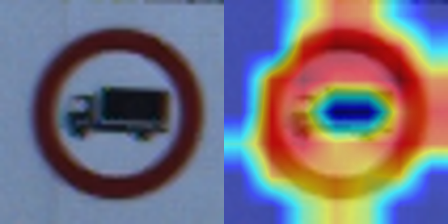

In [8]:
def benchmark(_img_example, input_tensor, eigen_smooth=False, aug_smooth=False, category=None):
    targets = [ClassifierOutputReST(category)]
    
    visualizations = []
    
    initial_image = Image.fromarray((_img_example * 255).astype(np.uint8))
    visualizations.append(initial_image)

    attributions = cam(input_tensor=input_tensor, 
                                targets=targets, eigen_smooth=eigen_smooth, aug_smooth=aug_smooth)
    attribution = attributions[0, :]   
    visualization = show_cam_on_image(_img_example, attribution, use_rgb=True, image_weight=0.5)
    visualizations.append(visualization)
    
    return Image.fromarray(np.hstack(visualizations))

img_example = np.array(Image.open("./data/Test/00000.png"))
category = 16

img_example = np.array(Image.fromarray(img_example).resize((224, 224)))
img_example = np.float32(img_example) / 255
preprocessing = Compose([
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
input_tensor = preprocessing(img_example.copy()).unsqueeze(0)


swin_model.to(device)
input_tensor = input_tensor.to(device)
np.random.seed(42)
benchmark(img_example, input_tensor, target_layers, category= category)

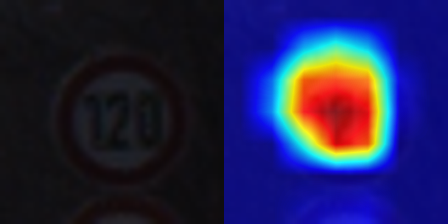

In [9]:
img_example = np.array(Image.open("./data/Test/00189.png"))
category = 8

img_example = np.array(Image.fromarray(img_example).resize((224, 224)))
img_example = np.float32(img_example) / 255
preprocessing = Compose([
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
input_tensor = preprocessing(img_example.copy()).unsqueeze(0)


swin_model.to(device)
input_tensor = input_tensor.to(device)
np.random.seed(42)
benchmark(img_example, input_tensor, target_layers, category= category)

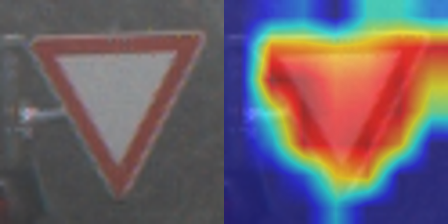

In [14]:
img_example = np.array(Image.open("./data/Test/00652.png"))
category = 13

img_example = np.array(Image.fromarray(img_example).resize((224, 224)))
img_example = np.float32(img_example) / 255
preprocessing = Compose([
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
input_tensor = preprocessing(img_example.copy()).unsqueeze(0)


swin_model.to(device)
input_tensor = input_tensor.to(device)
np.random.seed(42)
benchmark(img_example, input_tensor, target_layers, category= category)